In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,f1_score,roc_auc_score,confusion_matrix,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
import warnings
import  xgboost as xgb
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("../dataset/processed/feature_data.csv")

In [6]:
df.shape

(180516, 33)

## Data Preparation

Features rebuilt from clean_data.csv and train/test split applied.
80/20 split with stratify=y ensures both sets have the same class distribution.
Total features going into the model: shown above in X_train shape.

In [7]:
# After analysing the columns it seems some of the columns will cause data leak so we will be removeing them
leaky=['delay_gap','Days for shipping (real)', 
         'Days for shipment (scheduled)', 'Order_processing_days']
df.drop(columns=leaky,inplace=True)

# Chronological split
split_index=int(len(df)*0.8)
train_df = df.iloc[:split_index]  
test_df  = df.iloc[split_index:]  

x_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
x_test = test_df.drop(columns=['Late_delivery_risk'])
y_test = test_df['Late_delivery_risk']

print("X train :",x_train.shape)
print("X test :",x_test.shape)
print(f"Train Late Rate :{y_train.mean():.3f}")
print(f"Test Late Rate : {y_test.mean():.3f}")

X train : (144412, 28)
X test : (36104, 28)
Train Late Rate :0.549
Test Late Rate : 0.547


## Baseline: Logistic Regression

Logistic regression serves as our baseline. StandardScaler applied
since logistic regression is sensitive to feature scale.
class_weight='balanced' handles the class imbalance automatically.

This gives us a performance floor  any model we build must beat this.

In [8]:
# Building a Base Line Model
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(x_train_scaled, y_train)
lr_preds = lr.predict(x_test_scaled)
lr_proba = lr.predict_proba(x_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.79      0.84      0.81     16369
           1       0.86      0.81      0.84     19735

    accuracy                           0.83     36104
   macro avg       0.82      0.83      0.83     36104
weighted avg       0.83      0.83      0.83     36104

AUC-ROC: 0.9166


## Main Model: XGBoost Classifier

XGBoost is our primary model. Key parameters:
- n_estimators=200: number of trees
- max_depth=6: controls overfitting
- learning_rate=0.1: step size per tree
- subsample + colsample_bytree=0.8: random sampling for robustness

No scaling needed tree based models are scale invariant.

In [9]:
xgb_model=xgb.XGBClassifier( n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42)
xgb_model.fit(x_train,y_train)
xgb_preds=xgb_model.predict(x_test)
xgb_proba = xgb_model.predict_proba(x_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print(f"AUC-ROC: {roc_auc_score(y_test,xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.80      0.85      0.83     16369
           1       0.87      0.83      0.85     19735

    accuracy                           0.84     36104
   macro avg       0.84      0.84      0.84     36104
weighted avg       0.84      0.84      0.84     36104

AUC-ROC: 0.9316


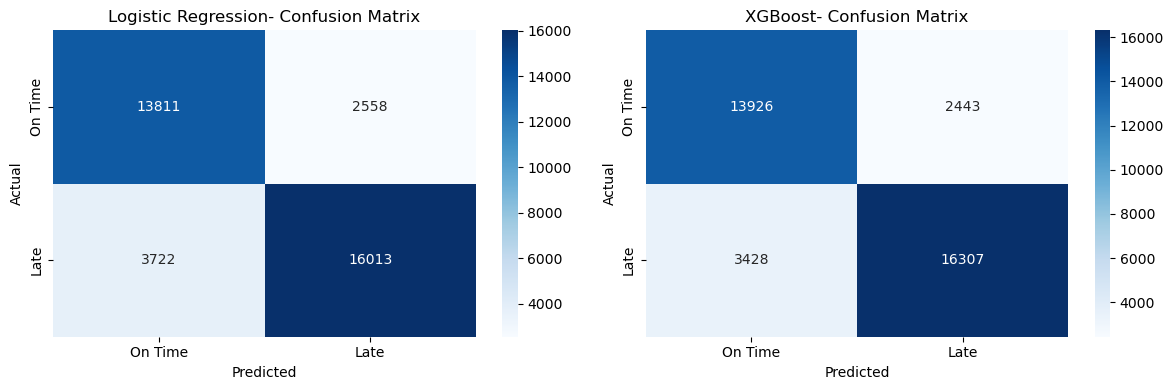

In [10]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

for ax,pred,title in zip(axes,[lr_preds,xgb_preds],['Logistic Regression',"XGBoost"]):
    cm=confusion_matrix(y_test,pred)
    sns.heatmap(cm,annot=True,cmap="Blues",ax=ax,fmt="d",xticklabels=['On Time',"Late"],yticklabels=['On Time','Late'])
    ax.set_title(f"{title}- Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
import os
os.makedirs("reports/figures", exist_ok=True)
plt.savefig("reports/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

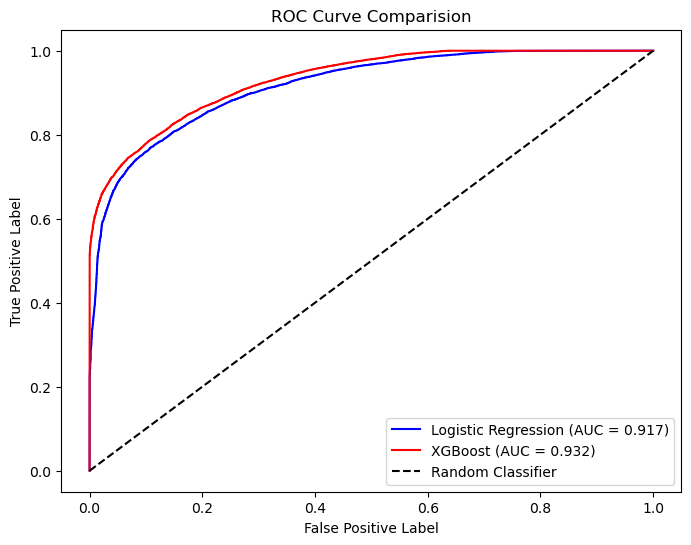

In [11]:
fig,ax=plt.subplots(figsize=(8,6))

for probs,label,color in zip([lr_proba,xgb_proba],["Logistic Regression","XGBoost"],['blue','red']):
    fpr,tpr,_=roc_curve(y_test,probs)
    auc=roc_auc_score(y_test,probs)
    ax.plot(fpr,tpr,label=f"{label} (AUC = {auc:.3f})",color=color)
ax.plot([0,1],[0,1],'k--',label='Random Classifier')
ax.set_xlabel("False Positive Label")
ax.set_ylabel("True Positive Label")
ax.set_title("ROC Curve Comparision")
ax.legend()
plt.savefig("reports/figures/roc_curve.png",dpi=150,bbox_inches="tight")
plt.show()

## ROC Curve Comparison

AUC-ROC measures the model's ability to distinguish between late and
on-time shipments across all classification thresholds.

AUC = 1.0 is perfect. AUC = 0.5 is random guessing.


In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1 Score': [
        f1_score(y_test, lr_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted')
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
}).round(4)

print(results.to_string(index=False))

              Model  F1 Score  AUC-ROC
Logistic Regression    0.8264   0.9166
            XGBoost    0.8377   0.9316


In [13]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgb_classifier.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Models saved.")

Models saved.


In [14]:
import shap
shap.initjs()

In [15]:
explainer=shap.TreeExplainer(xgb_model)
shap_values=explainer(x_test)

print("Shap Values Computed")
print(f"Shape : {shap_values.shape}")

Shap Values Computed
Shape : (36104, 28)


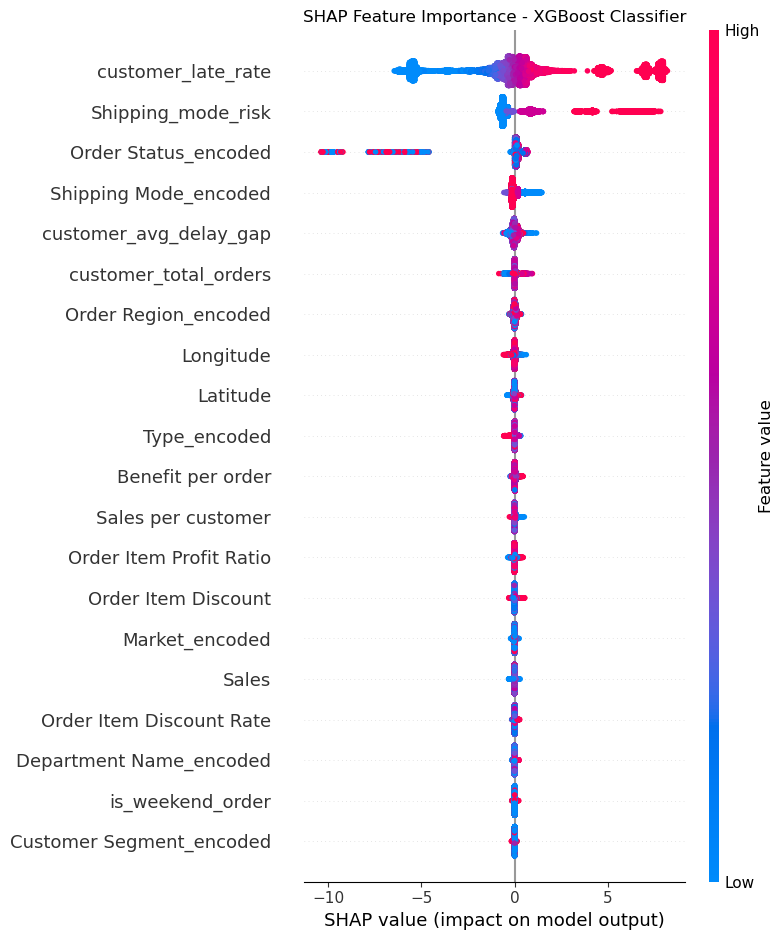

In [16]:
plt.figure()
shap.summary_plot(shap_values,x_test,show=False)
plt.title("SHAP Feature Importance - XGBoost Classifier")
plt.tight_layout()
plt.savefig("reports/figures/shap_summary.png",dpi=150,bbox_inches='tight')
plt.show()

## SHAP Summary Plot

SHAP (SHapley Additive exPlanations) shows not just WHICH features
matter but HOW they affect predictions.

- Features are ranked by mean absolute SHAP value (most important at top)
- Each dot = one prediction
- Red dots = high feature value, Blue = low feature value
- Dots on the right = pushed prediction toward "late"
- Dots on the left = pushed prediction toward "on time"

This goes beyond standard feature importance  it shows directionality.
High Shipping_mode_risk (red) pushing right confirms that premium shipping
modes increase late delivery probability.

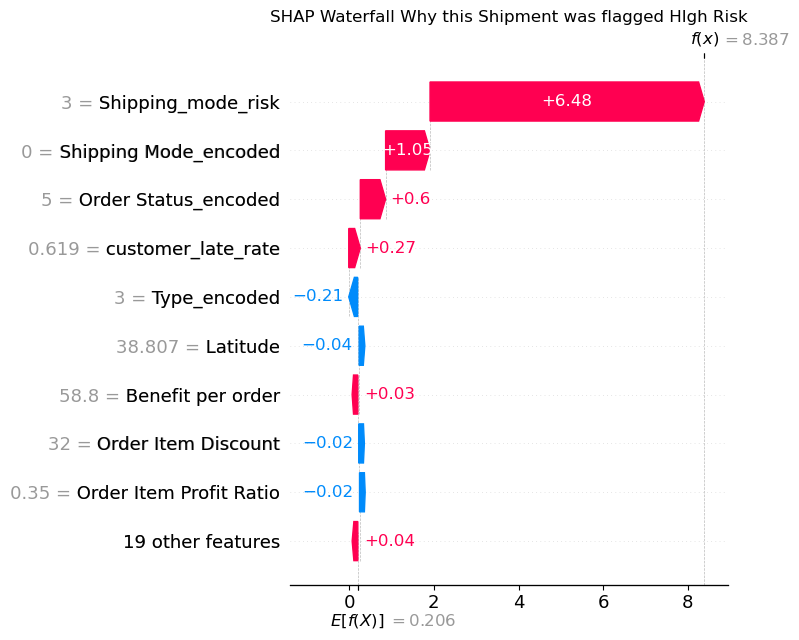

In [17]:
# Pick the first high risk prediction in the test set
high_risk_idx=(xgb_proba>0.8).argmax()
plt.figure()
shap.plots.waterfall(shap_values[high_risk_idx],show=False)
plt.title("SHAP Waterfall Why this Shipment was flagged HIgh Risk")
plt.tight_layout()
plt.savefig('reports/figures/shap_waterfall.png',dpi=150,bbox_inches='tight')
plt.show()

## SHAP Waterfall Plot Individual Prediction Explanation

The waterfall plot explains a single high-risk prediction in plain terms.

- E[f(x)] at the bottom = the model's average prediction (base rate)
- Each bar shows how much one feature pushed the prediction up or down
- f(x) at the top = the final prediction for this specific shipment

Red bars = features pushing toward "late"  
Blue bars = features pushing toward "on time"



In [18]:
import joblib

shap_df = pd.DataFrame(shap_values.values, columns=x_test.columns)
shap_df.to_csv('reports/shap_values.csv', index=False)

joblib.dump(explainer, 'models/shap_explainer.pkl')
print("SHAP values and explainer saved.")

SHAP values and explainer saved.
